In [1]:
import importlib.util

if importlib.util.find_spec('nest_asyncio') is None:
    print('Installing nest_asnycio')
    %pip install nest_asyncio
if importlib.util.find_spec('bleak') is None:
    print('Installing bleak')
    %pip install bleak

import nest_asyncio
nest_asyncio.apply()

import movesense as ms
import asyncio

END_OF_SERIAL = 1465

async def main():
    device = await ms.scan(END_OF_SERIAL)

asyncio.run(main())

Device found:  Movesense 213030001465
Address:  0C:8C:DC:3C:9D:19


Device found:  Movesense 213030001465
Address:  0C:8C:DC:3C:9D:19

In [6]:
import importlib.util

if importlib.util.find_spec('nest_asyncio') is None:
    print('Installing nest_asnycio')
    %pip install nest_asyncio
if importlib.util.find_spec('bleak') is None:
    print('Installing bleak')
    %pip install bleak

import nest_asyncio
nest_asyncio.apply()

import asyncio
import movesense as ms
import matplotlib.pyplot as plt



# DEVICE SETTINGS

ADDRESS = "0C:8C:DC:3C:9D:19" # Movesense address

# SUBSCRIBTION SETTINGS
# Refer to API for samplerates
# https://movesense.com/docs/esw/api_reference

SENSOR = ms.Sensor.IMU9

SAMPLERATE = 104 # Depends on sensor

REC_LENGTH = 35 # In seconds

START_DELAY = 5 # Wait N seconds after connecting

FILEPATH = "../../data/movesense/" # CSV save location (FOLDER MUST EXIST)

SAVE_TO_CSV = True # Option to disable saving data to a CSV.


device = ms.MovesenseClient(ADDRESS)

async def main():
    async with device as client:
        record = await client.subscribe(
            sensor=SENSOR, 
            samplerate=SAMPLERATE, 
            rec_length=REC_LENGTH, 
            start_delay=START_DELAY, 
            filepath=FILEPATH,
            save_to_csv=True
        )
    
        df = record.to_pandas()
        print(df.tail(5))
    
asyncio.run(main())

(ms1465) Connected
(ms1465) Recording starts in 5 seconds
(ms1465) Recording imu9 @ 104Hz
(ms1465) Recording complete
File created at: ../../data/movesense/ms1465_imu9_2025-11-05_20-04-39.csv
      Timestamp    AccX   AccY   AccZ   GyroX  GyroY  GyroZ  MagnX  MagnY  \
3635        NaN  12.718  5.463 -1.840   5.011  0.043 -2.682 -15.33 -76.72   
3636    75901.0   4.815  0.804 -4.197   7.597 -4.604 -6.298 -16.87 -46.69   
3637        NaN   7.286  0.151 -6.368   9.273 -3.295 -5.068 -31.43 -63.35   
3638        NaN   8.957 -1.661 -7.167  11.096 -1.819 -4.267 -44.73 -65.38   
3639        NaN   8.155 -3.664 -7.578  11.084 -0.976 -4.238 -42.28 -59.64   

      MagnZ  
3635  27.16  
3636  43.54  
3637  48.86  
3638  48.72  
3639  37.24  
(ms1465) Disconnected


✅ Suodatettu data tallennettu: ../../data/movesense/testeja/testi_kyykky_oj_2025-11-5_filtered.csv


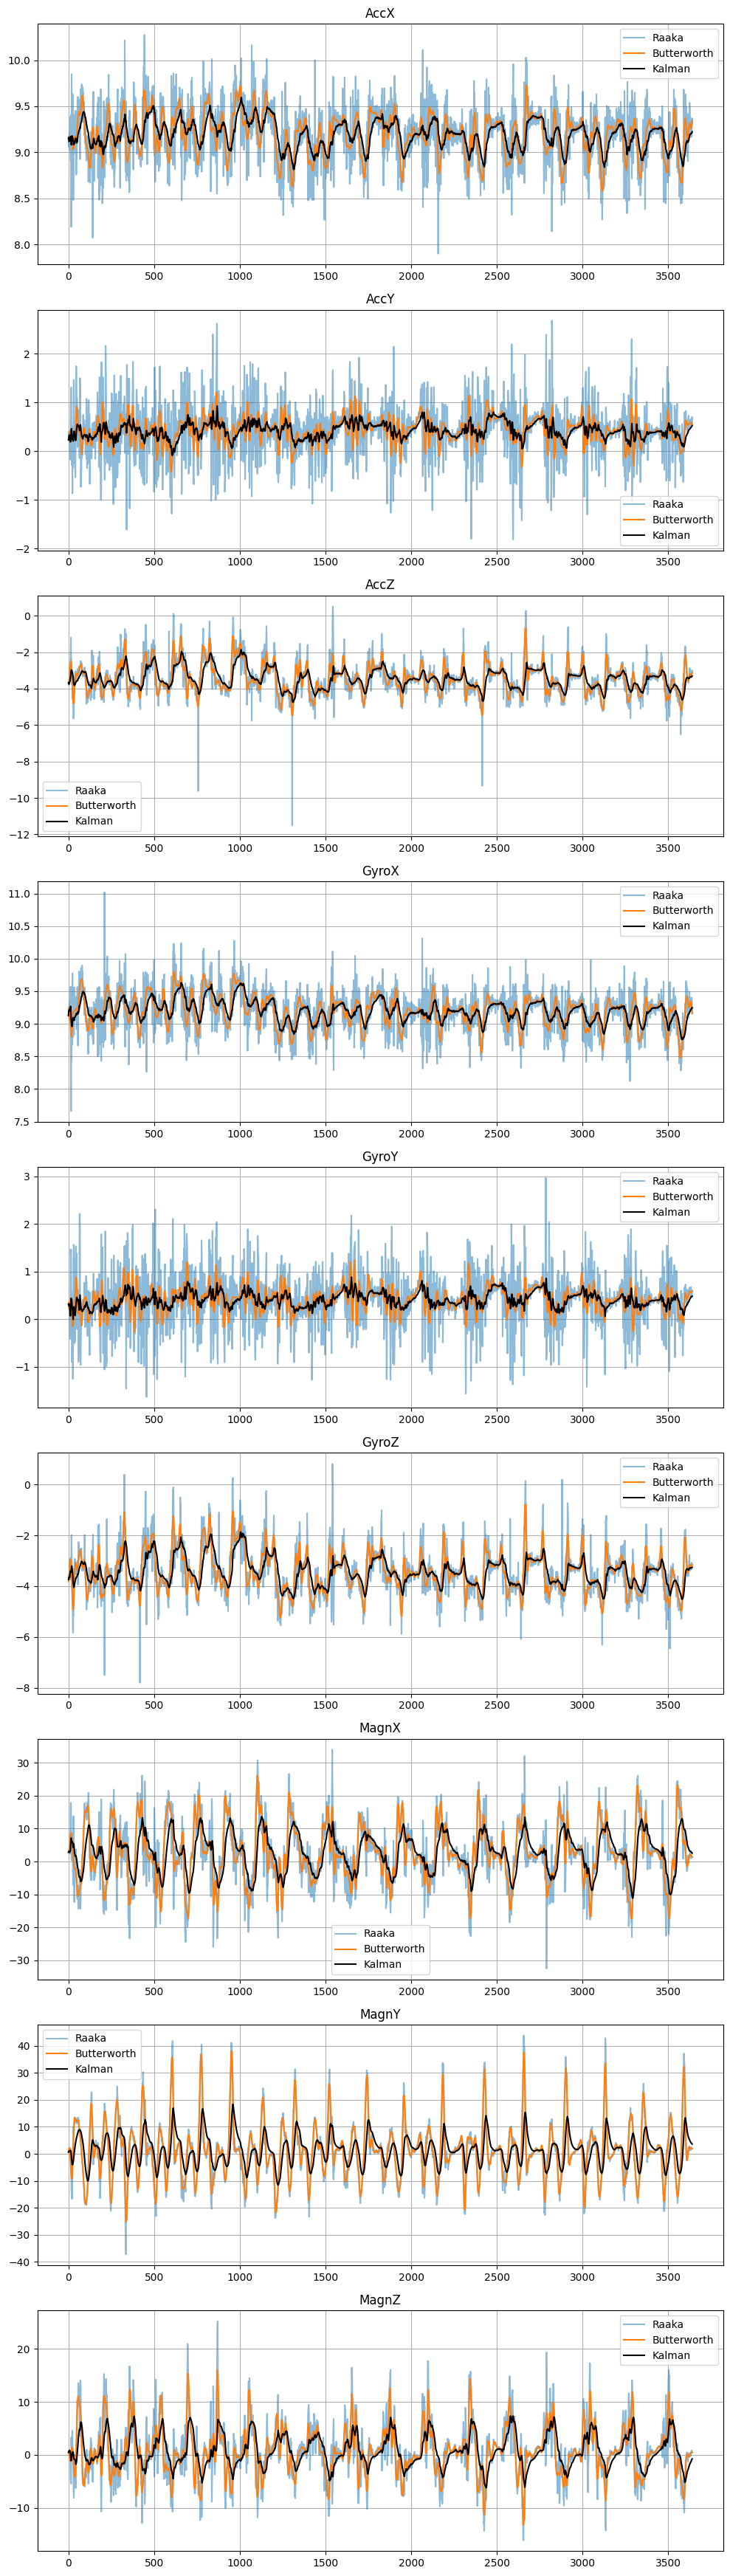

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Kalman-suodatin (yksinkertainen) ---
class SimpleKalman:
    def __init__(self, process_var=1e-4, meas_var=0.05):
        self.process_var = process_var
        self.meas_var = meas_var
        self.initialized = False

    def filter(self, data):
        estimates = []
        for measurement in data:
            if not self.initialized:
                self.posteri_estimate = measurement  # <-- старт с реального значения
                self.posteri_error_estimate = 1.0
                self.initialized = True
            priori_estimate = self.posteri_estimate
            priori_error_estimate = self.posteri_error_estimate + self.process_var
            kalman_gain = priori_error_estimate / (priori_error_estimate + self.meas_var)
            self.posteri_estimate = priori_estimate + kalman_gain * (measurement - priori_estimate)
            self.posteri_error_estimate = (1 - kalman_gain) * priori_error_estimate
            estimates.append(self.posteri_estimate)
        return np.array(estimates)

# --- Butterworth-suodatin ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# --- Pääfunktio ---
def process_imu_data(filename, fs=104, cutoff=5, order=4, save=True, plot=True, drop_n=0):
    df = pd.read_csv(filename)

    if len(df) > drop_n:
        df = df.iloc[drop_n:].reset_index(drop=True)
    else:
        raise ValueError(f"Tiedosto on liian lyhyt ({len(df)} riviä) - ei voi poistaa {drop_n} riviä.")


    columns = ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','MagnX','MagnY','MagnZ']

    for col in columns:
        raw = df[col].values
        df[f'{col}_butter'] = butter_lowpass_filter(raw, cutoff, fs, order)
        kalman = SimpleKalman()
        df[f'{col}_kalman'] = kalman.filter(raw)

    if save:
        output_name = filename.replace('.csv', '_filtered.csv')
        df.to_csv(output_name, index=False)
        print(f"✅ Suodatettu data tallennettu: {output_name}")

    if plot:
        # Näytetään esim. AccX, AccY, AccZ ennen/jälkeen suodatuksen
        fig, axes = plt.subplots(9, 1, figsize=(10, 35))
        for i, axis in enumerate(['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'MagnX', 'MagnY', 'MagnZ']):
            axes[i].plot(df.index, df[axis], alpha=0.5, label='Raaka')
            axes[i].plot(df.index, df[f'{axis}_butter'], label='Butterworth')
            axes[i].plot(df.index, df[f'{axis}_kalman'], label='Kalman', color='black')
            axes[i].set_title(axis)
            axes[i].legend()
            axes[i].grid(True)
        plt.tight_layout()
        plt.show()

    return df

# --- Käyttöesimerkki ---
if __name__ == "__main__":
    
    df_filtered = process_imu_data("../../data/movesense/testeja/testi_kyykky_oj_2025-11-5.csv")


✅ Загружено 2080 измерений

--- Инициализация ---
Средние значения гироскопа: {'GyroX': -0.11924799999999999, 'GyroY': -9.937893, 'GyroZ': -0.058982}
⚠️ Внимание: датчик двигался в стартовом окне — bias может быть неверным!
Используется bias гироскопа: {'GyroX': -0.11924799999999999, 'GyroY': -9.937893, 'GyroZ': -0.058982}
Начальные углы: roll=-90.34°, pitch=0.68°
   up: roll=-90.34, pitch=0.68, score=91.02
 down: roll=89.66, pitch=-0.68, score=90.35
 left: roll=-90.34, pitch=0.68, score=91.02
right: roll=-90.34, pitch=0.68, score=91.02
front: roll=89.17, pitch=89.32, score=178.49
 back: roll=-90.83, pitch=-89.32, score=180.15
✅ Определена ориентация монтажа: down

💾 Результаты сохранены в angles_result_v2.csv


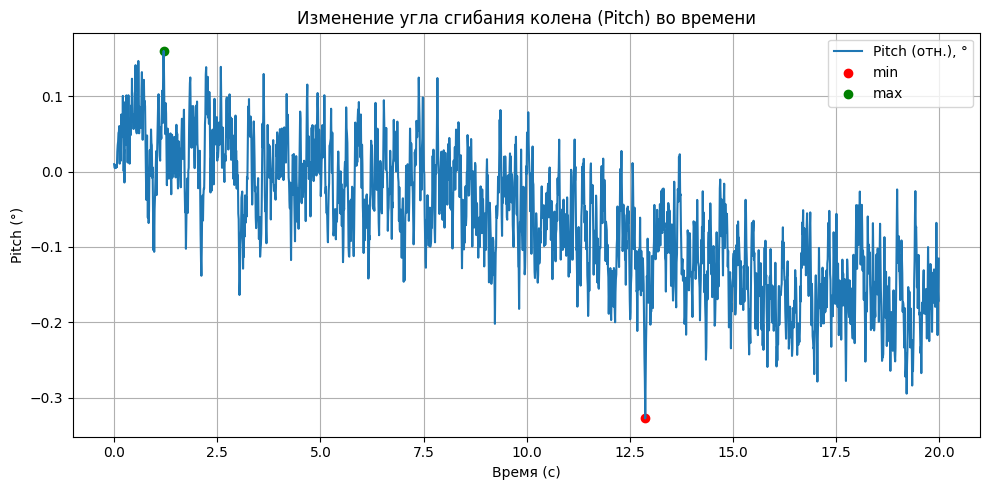

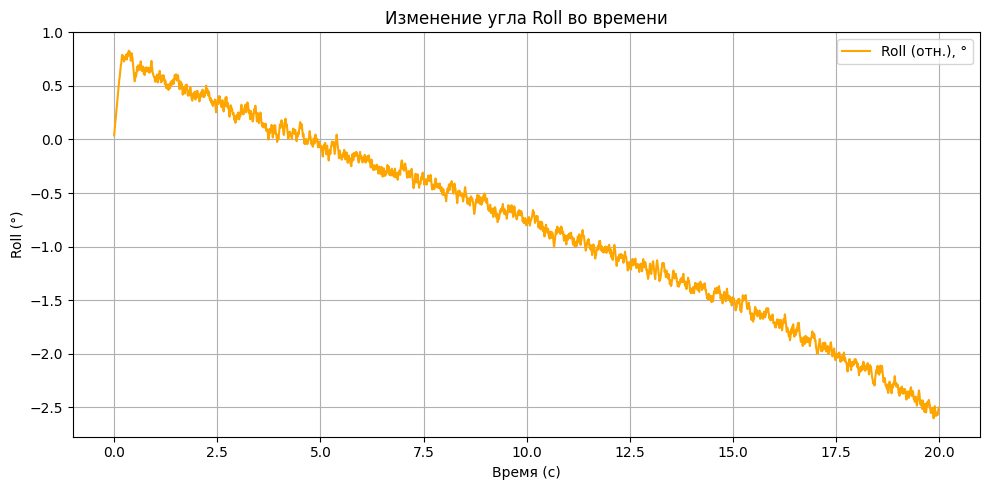

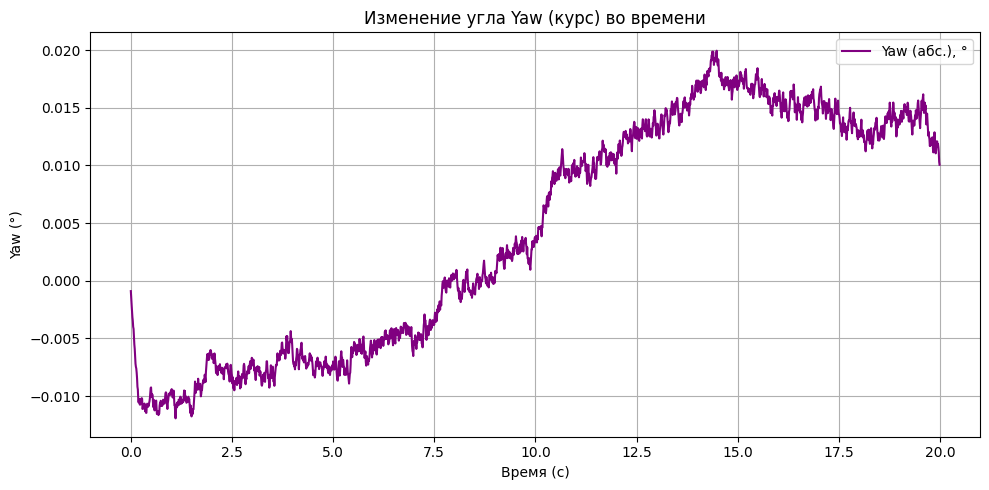

In [3]:
# compute_angles_v2.py — улучшенная и безопасная версия
# Полная ориентация IMU (Acc + Gyro + Mag) с авто-калибровкой и проверкой монтажа

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ahrs.filters import Madgwick
from scipy.spatial.transform import Rotation as R

# === Параметры ===
FILE_IN  = "../../data/movesense/calib/back(calib-5).csv"
FILE_OUT = "angles_result_v2.csv"

FS = 104.0            # Частота дискретизации (Hz)
USE_MAG = False        # Использовать магнитометр (True = 9DOF)
INIT_WINDOW = 1000      # Сколько первых сэмплов взять для инициализации (≈2с)
BETA = 0.05            # Madgwick параметр
GYRO_BIAS = None       # {'GyroX':..., 'GyroY':..., 'GyroZ':...} или None

# === Загрузка данных ===
df = pd.read_csv(FILE_IN)
acc_cols = ['AccX', 'AccY', 'AccZ']
gyr_cols = ['GyroX', 'GyroY', 'GyroZ']
mag_cols = ['MagnX', 'MagnY', 'MagnZ']

for c in acc_cols + gyr_cols + mag_cols:
    if c not in df.columns:
        raise ValueError(f"❌ Missing column: {c}")

N = len(df)
print(f"✅ Загружено {N} измерений")

# === Проверка стартового окна (для покоя) ===
init_df = df.iloc[:INIT_WINDOW]
gyro_mean = init_df[gyr_cols].mean()
acc_mean = init_df[acc_cols].mean()
print("\n--- Инициализация ---")
print("Средние значения гироскопа:", gyro_mean.to_dict())
if np.any(np.abs(gyro_mean) > 1.0):
    print("⚠️ Внимание: датчик двигался в стартовом окне — bias может быть неверным!")

# === Калибровка гироскопа ===
if GYRO_BIAS is None:
    GYRO_BIAS = {col: float(gyro_mean[col]) for col in gyr_cols}
print("Используется bias гироскопа:", GYRO_BIAS)

gyr = (df[gyr_cols] - pd.Series(GYRO_BIAS)).to_numpy(dtype=float) * (np.pi / 180.0)  # deg/s → rad/s

# === Нормализация акселерометра и магнитометра ===
def normalize(v):
    norms = np.linalg.norm(v, axis=1)
    v_norm = np.zeros_like(v)
    mask = norms > 0
    v_norm[mask] = (v[mask].T / norms[mask]).T
    return v_norm

acc_raw = df[acc_cols].to_numpy(dtype=float)
acc = normalize(acc_raw)
mag_raw = df[mag_cols].to_numpy(dtype=float)
mag = normalize(mag_raw)

# === Инициализация ориентации ===
acc0 = np.mean(acc_raw[:INIT_WINDOW], axis=0)
ax, ay, az = acc0
roll0 = np.arctan2(ay, az)
pitch0 = np.arctan2(-ax, np.sqrt(ay*ay + az*az))
yaw0 = 0.0
r0 = R.from_euler('xyz', [roll0, pitch0, yaw0])
q0 = r0.as_quat()  # [x, y, z, w]
q = np.array([q0[3], q0[0], q0[1], q0[2]])  # scalar-first для Madgwick

print(f"Начальные углы: roll={np.degrees(roll0):.2f}°, pitch={np.degrees(pitch0):.2f}°")

# === Фильтр Madgwick ===
madgwick = Madgwick(sampleperiod=1.0 / FS, beta=BETA)
quaternions = np.zeros((N, 4))
for i in range(N):
    if USE_MAG:
        q = madgwick.updateMARG(q, gyr=gyr[i], acc=acc[i], mag=mag[i])
    else:
        q = madgwick.updateIMU(q, gyr=gyr[i], acc=acc[i])
    quaternions[i, :] = q

# === Кватернионы → Эйлер ===
quat_scipy = np.column_stack((quaternions[:,1], quaternions[:,2], quaternions[:,3], quaternions[:,0]))
rot = R.from_quat(quat_scipy)

# === Автоопределение ориентации монтажа ===
candidates = {
    'up': R.from_euler('xyz', [0,0,0], degrees=True),
    'down': R.from_euler('xyz', [180,0,0], degrees=True),
    'left': R.from_euler('xyz', [0,0,90], degrees=True),
    'right': R.from_euler('xyz', [0,0,-90], degrees=True),
    'front': R.from_euler('xyz', [0,90,0], degrees=True),
    'back': R.from_euler('xyz', [0,-90,0], degrees=True),
}
best, best_score = None, 1e9
for name, Rcorr in candidates.items():
    rot_test = Rcorr * rot
    euler_test = np.degrees(rot_test.as_euler('xyz', degrees=False))
    init_roll = np.mean(euler_test[:INIT_WINDOW,0])
    init_pitch = np.mean(euler_test[:INIT_WINDOW,1])
    score = abs(init_roll) + abs(init_pitch)
    print(f"{name:>5s}: roll={init_roll:.2f}, pitch={init_pitch:.2f}, score={score:.2f}")
    if score < best_score:
        best_score, best = score, name
print(f"✅ Определена ориентация монтажа: {best}")
R_sensor_to_body = candidates[best]

# === Применяем ориентацию ===
rot_body = R_sensor_to_body * rot
euler_deg = np.degrees(rot_body.as_euler('xyz', degrees=False))  # roll, pitch, yaw в системе тела
df['roll'] = euler_deg[:, 0]
df['pitch'] = euler_deg[:, 1]
df['yaw'] = euler_deg[:, 2]

# === Нормализация углов по начальному окну ===
init_roll_mean = np.mean(df['roll'].iloc[:INIT_WINDOW])
init_pitch_mean = np.mean(df['pitch'].iloc[:INIT_WINDOW])
df['roll_rel'] = df['roll'] - init_roll_mean
df['pitch_rel'] = df['pitch'] - init_pitch_mean

# === Сохранение ===
cols_out = acc_cols + gyr_cols + mag_cols + ['roll', 'pitch', 'yaw', 'roll_rel', 'pitch_rel']
df[cols_out].to_csv(FILE_OUT, index=False)
print(f"\n💾 Результаты сохранены в {FILE_OUT}")

# === График ===
t = np.arange(N) / FS
plt.figure(figsize=(10,5))
plt.plot(t, df['pitch_rel'], label='Pitch (отн.), °')
plt.xlabel('Время (с)')
plt.ylabel('Pitch (°)')
plt.title('Изменение угла сгибания колена (Pitch) во времени')
plt.grid()
min_idx = df['pitch_rel'].idxmin()
max_idx = df['pitch_rel'].idxmax()
plt.scatter([min_idx / FS], [df['pitch_rel'].iloc[min_idx]], color='r', label='min')
plt.scatter([max_idx / FS], [df['pitch_rel'].iloc[max_idx]], color='g', label='max')
plt.legend()
plt.tight_layout()
plt.show()

# === Дополнительные графики roll и yaw ===
plt.figure(figsize=(10, 5))
plt.plot(t, df['roll_rel'], label='Roll (отн.), °', color='orange')
plt.xlabel('Время (с)')
plt.ylabel('Roll (°)')
plt.title('Изменение угла Roll во времени')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, df['yaw'], label='Yaw (абс.), °', color='purple')
plt.xlabel('Время (с)')
plt.ylabel('Yaw (°)')
plt.title('Изменение угла Yaw (курс) во времени')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

